In [6]:
import torch
from torchvision import datasets, transforms

transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
)
mnist_train = datasets.MNIST(
    root="./data", train=True, download=False, transform=transform
)
mnist_test = datasets.MNIST(
    root="./data", train=False, download=False, transform=transform
)

# Stack images: result shape -> (N, 1, 28, 28)
X_train = torch.stack(
    [mnist_train[i][0] for i in range(len(mnist_train))]
)  # -> (N,1,28,28)
# Labels: result shape -> (N,)
y_train = torch.tensor([mnist_train[i][1] for i in range(len(mnist_train))])  # -> (N,)

device = "mps" if torch.backends.mps.is_available() else "cpu"  # device string
# moving tensors to device preserves shapes
X_train = X_train.to(device)  # -> (N,1,28,28)
y_train = y_train.to(device)  # -> (N,)

# Test set: (M,1,28,28) and (M,) respectively
X_test = torch.stack([mnist_test[i][0] for i in range(len(mnist_test))]).to(
    device
)  # -> (M,1,28,28)
y_test = torch.tensor([mnist_test[i][1] for i in range(len(mnist_test))]).to(
    device
)  # -> (M,)


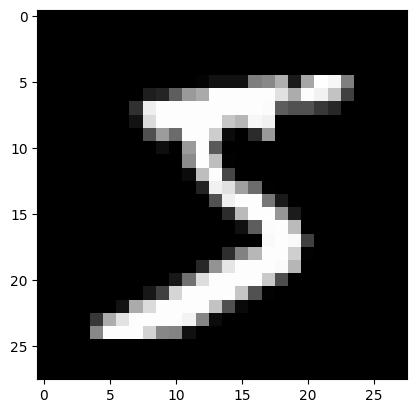

In [8]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0].cpu().permute(1, 2, 0), cmap="gray")

In [9]:
X_train[0].permute(1, 2, 0).shape

torch.Size([28, 28, 1])

In [11]:
import torch

import torch.nn as nn

class ConvolutionBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=(3, 3), **kwargs):
        super().__init__()
        self.conv = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=1, padding=0, **kwargs)
        self.bnorm = nn.BatchNorm2d(out_channels)
        self.act = nn.SiLU()
        
    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(0)
        if x.dim() == 2:
            x = x.unsqueeze(0).unsqueeze(0)
        x = self.conv(x)
        x = self.bnorm(x)
        x = self.act(x)
        return x  # keep spatial dims for next conv

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.blocks = nn.ModuleList([
            ConvolutionBlock(1, 8, kernel_size=(1, 1)),
            ConvolutionBlock(8, 16, kernel_size=(1, 1))
        ])
        # infer flattened size using a dummy input
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 28, 28)
            out = dummy
            for b in self.blocks:
                out = b(out)
            flat_dim = out.view(1, -1).size(1)
        self.fc = nn.Linear(flat_dim, 10)
        
    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        x = x.view(x.size(0), -1)
        out = self.fc(x)
        return out
    
model = CNNModel().to(device)
model(X_train[0])


tensor([[ 0.3408,  0.0517,  0.3156,  0.1719,  0.2825, -0.2228,  0.0017, -0.4680,
          0.4656,  0.2968]], device='mps:0', grad_fn=<LinearBackward0>)

In [15]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5
batch_size = 64
num_samples = X_train.size(0)

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for i in range(0, num_samples, batch_size):
        X_batch = X_train[i : i + batch_size]
        y_batch = y_train[i : i + batch_size]

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()  # Clear gradients

        epoch_loss += loss.item() * X_batch.size(0)

    avg_loss = epoch_loss / num_samples
    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.4f}")


Epoch 1/5, Loss: 0.1880
Epoch 2/5, Loss: 0.1751
Epoch 3/5, Loss: 0.1668
Epoch 4/5, Loss: 0.1624
Epoch 5/5, Loss: 0.1547


In [16]:
model.eval()
with torch.no_grad():
    val = model(X_test)

    # count correct predictions
    _, predicted = torch.max(val, 1)
    correct = (predicted == y_test).sum().item()
    total = y_test.size(0)
    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")


Test Accuracy: 0.8900
